Authors: Malcolm Zartman & Evan Peterson

Sharable Link: https://colab.research.google.com/drive/1htFGc7tFcZJiek5XRTkT4PbPg9ea6CTo?usp=sharing

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar100

In [ ]:
epochs = 25
batch_size = 128
max_pooling_size = 2
padding = 'same'
optimizer_type = 'adam'

num_classes = 100
input_shape = (32, 32, 3)

In [ ]:
# Load and split data
(x_train, y_train), (x_test, y_test) = cifar100.load_data(label_mode='fine')

# Normalize pixel values
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print(f"Training data shape: {x_train.shape}")
print(f"Test data shape: {x_test.shape}")

# Load labels
try:
    labels = np.loadtxt("cifar100labels-1.txt", delimiter=',', dtype=str)
    print("Labels loaded successfully.")
except:
    print("Warning: cifar100labels.txt not found. Please upload it to the folder icon on the left.")

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)


In [ ]:
def build_model(dropout_rate=0.0, filters=32):
    model = models.Sequential()

    # Input + Conv + Pooling
    model.add(layers.Conv2D(filters, (3, 3), padding=padding, input_shape=input_shape, activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(max_pooling_size, max_pooling_size)))

    # Conv + Pooling
    model.add(layers.Conv2D(filters * 2, (3, 3), padding=padding, activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(max_pooling_size, max_pooling_size)))

    # Conv + Pooling
    model.add(layers.Conv2D(filters * 4, (3, 3), padding=padding, activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(max_pooling_size, max_pooling_size)))

    # Flatten + Dense (Hidden Layer)
    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))

    # Output Layer
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

# Create initial model
model = build_model(dropout_rate=0.0)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 643,492 (2.45 MB)

 Trainable params: 643,492 (2.45 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile
model.compile(optimizer=optimizer_type,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Fit
history = model.fit(x_train, y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_data=(x_test, y_test))

Epoch 1/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.1153 - loss: 3.8649 - val_accuracy: 0.2074 - val_loss: 3.3350
Epoch 2/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.2495 - loss: 3.0721 - val_accuracy: 0.2862 - val_loss: 2.8797
Epoch 3/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.3267 - loss: 2.6713 - val_accuracy: 0.3405 - val_loss: 2.6577
Epoch 4/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3838 - loss: 2.4054 - val_accuracy: 0.3679 - val_loss: 2.4985
Epoch 5/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4275 - loss: 2.1990 - val_accuracy: 0.3862 - val_loss: 2.4085
Epoch 6/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4668 - loss: 2.0263 - val_accuracy: 0.4008 - val_loss: 2.3906
Epoch 7/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5026 - loss: 1.8680 - val_accuracy: 0.4052 - val_loss: 2.3655
Epoch 8/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5340 - loss: 1.7249 - val_accuracy: 

In [ ]:
# Evaluate accuracy
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'\nTest Accuracy: {test_acc*100:.2f}%')

313/313 - 2s - 6ms/step - accuracy: 0.3882 - loss: 5.1531

Test Accuracy: 38.82%


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 626ms/step


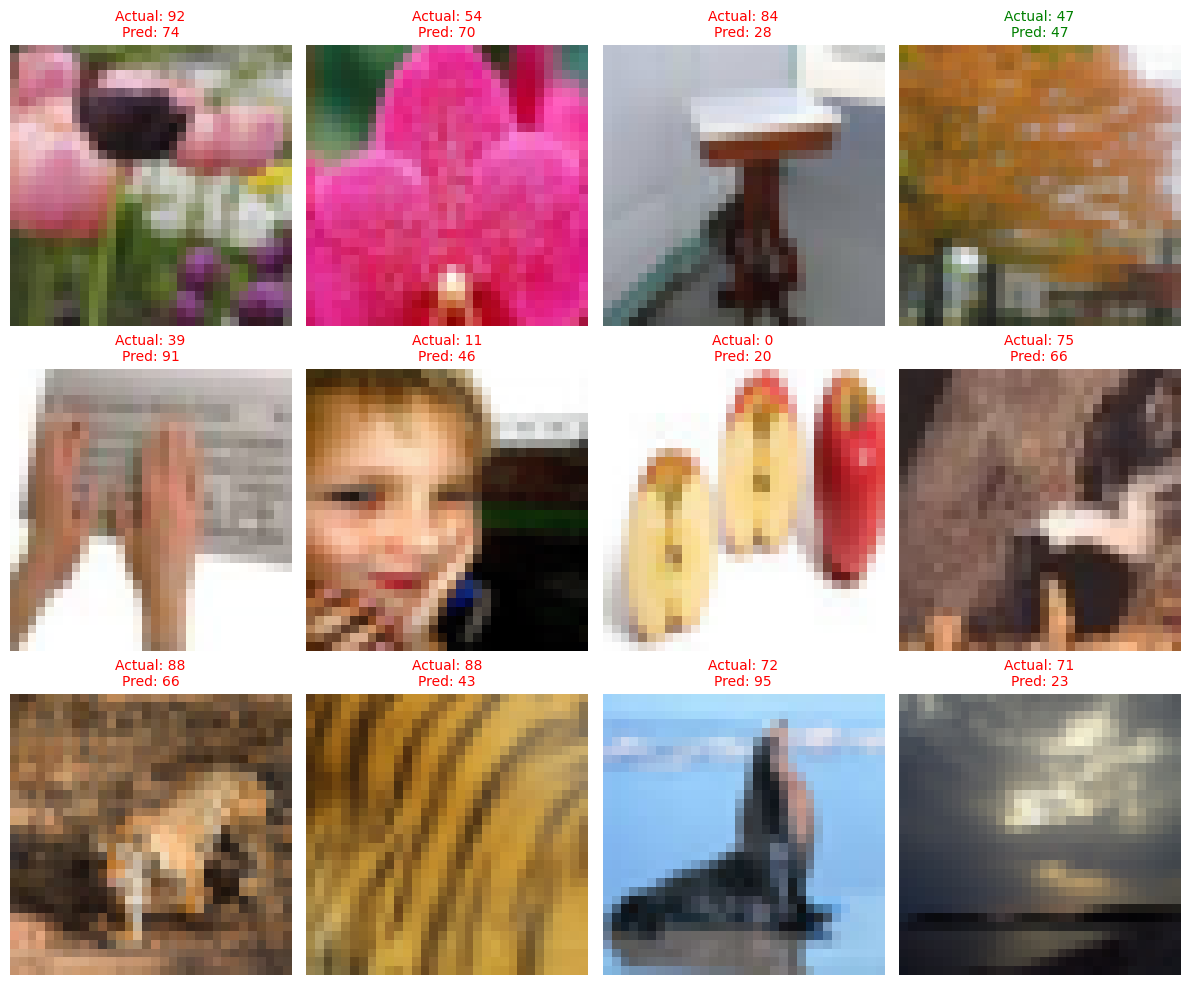

In [ ]:
# Random subsample of 12 images
random_indices = np.random.choice(range(len(x_test)), 12, replace=False)
sample_images = x_test[random_indices]
sample_labels = y_test[random_indices]

# Generate predictions
predictions = model.predict(sample_images)
predicted_indices = np.argmax(predictions, axis=1)

# Plotting
plt.figure(figsize=(12, 10))
for i in range(12):
    plt.subplot(3, 4, i+1)
    plt.imshow(sample_images[i])

    actual_name = labels[sample_labels[i][0]] if 'labels' in locals() else sample_labels[i][0]
    pred_name = labels[predicted_indices[i]] if 'labels' in locals() else predicted_indices[i]

    color = 'green' if predicted_indices[i] == sample_labels[i] else 'red'
    plt.title(f"Actual: {actual_name}\nPred: {pred_name}", color=color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Tuning with Dropout and more filters
tuned_model = build_model(dropout_rate=0.3, filters=64)
tuned_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
tuned_model.fit(x_train, y_train, epochs=25, batch_size=64) # Try smaller batch size too

Epoch 1/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.0936 - loss: 3.9558
Epoch 2/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.2249 - loss: 3.1637
Epoch 3/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.2984 - loss: 2.7806
Epoch 4/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3514 - loss: 2.5185
Epoch 5/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.3986 - loss: 2.2921
Epoch 6/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4396 - loss: 2.1016
Epoch 7/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4741 - loss: 1.9355
Epoch 8/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5101 - loss: 1.7748
Epoch 9/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5422 - loss: 1.6321
Epoch 10/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5774 - loss: 1.4847
Epoch 11/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6024 - loss: 1.3658
Epoch 12/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/st